# Bayan Student Notebook — 02_attention_transformers.ipynb

**Student:** Anas Ibrahim Al-Mutairi  
**GitHub:** `Ans212121`  
**Source:** reorganised from my own executed combined Bayan Colab notebook.

Run top-to-bottom in Google Colab and preserve the saved outputs before final submission.


# Day 1 — Notebook 2: Attention & Transformers

This section continues the Day 1 work and focuses on:
- Scaled Dot-Product Attention
- Q, K, and V matrices
- Attention scores and weights
- Transformer concepts

Notebook 1 completed successfully:
`DAY1_NOTEBOOK1_CORE=PASS`

In [15]:
import math
import numpy as np


def stable_softmax(values: np.ndarray, axis: int = -1) -> np.ndarray:
    shifted_values = values - np.max(values, axis=axis, keepdims=True)
    exp_values = np.exp(shifted_values)

    return exp_values / np.sum(
        exp_values,
        axis=axis,
        keepdims=True
    )


def compute_attention(
    queries: np.ndarray,
    keys: np.ndarray,
    values: np.ndarray,
    mask: np.ndarray | None = None
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:

    if queries.shape[-1] != keys.shape[-1]:
        raise ValueError(
            "Queries and keys must have the same feature size"
        )

    if keys.shape[-2] != values.shape[-2]:
        raise ValueError(
            "Keys and values must have the same sequence length"
        )

    attention_scores = (
        queries @ np.swapaxes(keys, -1, -2)
    ) / math.sqrt(queries.shape[-1])

    if mask is not None:
        mask_array = np.asarray(mask, dtype=bool)

        try:
            mask_array = np.broadcast_to(
                mask_array,
                attention_scores.shape
            )
        except ValueError as error:
            raise ValueError(
                "Mask shape cannot match attention scores"
            ) from error

        if np.any(mask_array.sum(axis=-1) == 0):
            raise ValueError(
                "Each query must keep at least one valid key"
            )

        attention_scores = np.where(
            mask_array,
            attention_scores,
            -np.inf
        )

    attention_weights = stable_softmax(
        attention_scores,
        axis=-1
    )

    attention_output = attention_weights @ values

    return (
        attention_output,
        attention_weights,
        attention_scores
    )


queries = np.array([
    [1.0, 0.0],
    [0.0, 1.0]
])

keys = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0]
])

values = np.array([
    [10.0, 0.0],
    [0.0, 10.0],
    [5.0, 5.0]
])


attention_output, attention_weights, attention_scores = compute_attention(
    queries,
    keys,
    values
)


print("Scores shape:", attention_scores.shape)

print(
    "Attention weights:\n",
    np.round(attention_weights, 3)
)

print(
    "Weight row sums:",
    attention_weights.sum(axis=-1)
)

print(
    "Attention output:\n",
    np.round(attention_output, 3)
)


assert attention_output.shape == (2, 2)

assert np.allclose(
    attention_weights.sum(axis=-1),
    1.0
)

print("Scaled attention=PASS")

Scores shape: (2, 3)
Attention weights:
 [[0.401 0.198 0.401]
 [0.198 0.401 0.401]]
Weight row sums: [1. 1.]
Attention output:
 [[6.017 3.983]
 [3.983 6.017]]
Scaled attention=PASS


In [16]:
# Compare attention with and without scaling

def calculate_entropy(probabilities: np.ndarray) -> float:
    safe_probs = np.clip(probabilities, 1e-12, 1.0)

    return float(
        -np.sum(
            safe_probs * np.log(safe_probs),
            axis=-1
        ).mean()
    )


query_matrix = np.random.default_rng(42).normal(
    size=(6, 64)
)

key_matrix = np.random.default_rng(43).normal(
    size=(6, 64)
)

raw_scores = query_matrix @ key_matrix.T

weights_without_scaling = stable_softmax(raw_scores)

weights_with_scaling = stable_softmax(
    raw_scores / math.sqrt(query_matrix.shape[-1])
)

entropy_without_scaling = calculate_entropy(
    weights_without_scaling
)

entropy_with_scaling = calculate_entropy(
    weights_with_scaling
)

print(
    "Mean entropy without scaling:",
    round(entropy_without_scaling, 3)
)

print(
    "Mean entropy with scaling:",
    round(entropy_with_scaling, 3)
)

print("Scaling comparison complete")

Mean entropy without scaling: 0.516
Mean entropy with scaling: 1.589
Scaling comparison complete


In [17]:
# Causal mask example

causal_mask = np.tril(
    np.ones((2, 3), dtype=bool)
)

masked_output, masked_weights, _ = compute_attention(
    queries,
    keys,
    values,
    mask=causal_mask
)

print(
    "Keep mask:\n",
    causal_mask.astype(int)
)

print(
    "Masked attention weights:\n",
    np.round(masked_weights, 3)
)

assert masked_weights[0, 1] == 0.0
assert masked_weights[0, 2] == 0.0

print("Mask semantics=PASS")

Keep mask:
 [[1 0 0]
 [1 1 0]]
Masked attention weights:
 [[1.   0.   0.  ]
 [0.33 0.67 0.  ]]
Mask semantics=PASS


In [18]:
# Split and combine Multi-Head representations

def split_into_heads(
    tensor: np.ndarray,
    num_heads: int
) -> np.ndarray:

    batch_size, seq_length, d_model = tensor.shape

    if d_model % num_heads != 0:
        raise ValueError(
            "d_model must be divisible by num_heads"
        )

    head_dim = d_model // num_heads

    reshaped = tensor.reshape(
        batch_size,
        seq_length,
        num_heads,
        head_dim
    )

    return reshaped.transpose(0, 2, 1, 3)


def combine_from_heads(
    tensor: np.ndarray
) -> np.ndarray:

    batch_size, num_heads, seq_length, head_dim = tensor.shape

    reordered = tensor.transpose(0, 2, 1, 3)

    return reordered.reshape(
        batch_size,
        seq_length,
        num_heads * head_dim
    )


random_generator = np.random.default_rng(42)

sample_tensor = random_generator.normal(
    size=(2, 5, 12)
)

head_tensor = split_into_heads(
    sample_tensor,
    num_heads=3
)

combined_tensor = combine_from_heads(
    head_tensor
)

print("Input shape:", sample_tensor.shape)

print(
    "Split shape:",
    head_tensor.shape,
    "= (batch, heads, tokens, head_dim)"
)

print("Combined shape:", combined_tensor.shape)

assert head_tensor.shape == (2, 3, 5, 4)
assert np.allclose(combined_tensor, sample_tensor)

print("Multi-head shape journey=PASS")

Input shape: (2, 5, 12)
Split shape: (2, 3, 5, 4) = (batch, heads, tokens, head_dim)
Combined shape: (2, 5, 12)
Multi-head shape journey=PASS


In [19]:
# Optional Transformer Encoder test with PyTorch

try:
    import torch

    torch.manual_seed(42)

    encoder_layer = torch.nn.TransformerEncoderLayer(
        d_model=12,
        nhead=3,
        dim_feedforward=24,
        dropout=0.0,
        batch_first=True,
        norm_first=False
    )

    encoder_layer.eval()

    torch_input = torch.tensor(
        sample_tensor,
        dtype=torch.float32
    )

    with torch.no_grad():
        encoder_output = encoder_layer(torch_input)

    print(
        "PyTorch encoder output shape:",
        tuple(encoder_output.shape)
    )

    assert tuple(encoder_output.shape) == (2, 5, 12)

    print("Optional encoder layer=PASS")

except ModuleNotFoundError:
    print(
        "PyTorch is not installed; NumPy Core is still complete."
    )

PyTorch encoder output shape: (2, 5, 12)
Optional encoder layer=PASS


In [20]:
# Compare our NumPy attention with PyTorch SDPA

try:
    import torch
    import torch.nn.functional as F

    torch_queries = torch.tensor(
        queries,
        dtype=torch.float64
    )[None, None, :, :]

    torch_keys = torch.tensor(
        keys,
        dtype=torch.float64
    )[None, None, :, :]

    torch_values = torch.tensor(
        values,
        dtype=torch.float64
    )[None, None, :, :]

    torch_result = F.scaled_dot_product_attention(
        torch_queries,
        torch_keys,
        torch_values,
        dropout_p=0.0
    )

    numpy_result = attention_output[None, None, :, :]

    max_difference = float(
        np.max(
            np.abs(
                torch_result.numpy() - numpy_result
            )
        )
    )

    print(
        "Maximum NumPy/PyTorch difference:",
        f"{max_difference:.3e}"
    )

    assert max_difference < 1e-9

    print("NumPy/PyTorch parity=PASS")

except ModuleNotFoundError:
    print(
        "PyTorch unavailable; parity check skipped without affecting Core."
    )

Maximum NumPy/PyTorch difference: 4.441e-16
NumPy/PyTorch parity=PASS


In [21]:
from transformers import AutoConfig

CHECKPOINTS_TO_AUDIT = [
    "google-bert/bert-base-multilingual-cased",
    "CAMeL-Lab/bert-base-arabic-camelbert-da",
]

EXPECTED_PARAMETER_TOTALS = {
    "google-bert/bert-base-multilingual-cased": 177_853_440,
    "CAMeL-Lab/bert-base-arabic-camelbert-da": 109_081_344,
}


def count_bert_parameters(model_name: str) -> dict:
    config = AutoConfig.from_pretrained(model_name)

    assert config.model_type == "bert"

    hidden_size = config.hidden_size
    intermediate_size = config.intermediate_size

    embedding_parameters = (
        config.vocab_size * hidden_size
        + config.max_position_embeddings * hidden_size
        + config.type_vocab_size * hidden_size
        + 2 * hidden_size
    )

    parameters_per_layer = (
        3 * (hidden_size * hidden_size + hidden_size)
        + (hidden_size * hidden_size + hidden_size)
        + 2 * hidden_size
        + (hidden_size * intermediate_size + intermediate_size)
        + (intermediate_size * hidden_size + hidden_size)
        + 2 * hidden_size
    )

    pooler_parameters = (
        hidden_size * hidden_size + hidden_size
    )

    total_parameters = (
        embedding_parameters
        + config.num_hidden_layers * parameters_per_layer
        + pooler_parameters
    )

    return {
        "model_name": model_name,
        "vocab_size": config.vocab_size,
        "total_parameters": total_parameters,
        "embedding_ratio": embedding_parameters / total_parameters,
    }


audit_results = [
    count_bert_parameters(model_name)
    for model_name in CHECKPOINTS_TO_AUDIT
]

for result in audit_results:
    print(
        f'{result["model_name"]} | '
        f'vocab={result["vocab_size"]:,} | '
        f'total={result["total_parameters"]:,} | '
        f'embeddings={result["embedding_ratio"]:.1%}'
    )

assert all(
    result["total_parameters"]
    == EXPECTED_PARAMETER_TOTALS[result["model_name"]]
    for result in audit_results
)

print("TWO_CHECKPOINT_PARAMETER_AUDIT=PASS")

google-bert/bert-base-multilingual-cased | vocab=119,547 | total=177,853,440 | embeddings=51.8%
CAMeL-Lab/bert-base-arabic-camelbert-da | vocab=30,000 | total=109,081,344 | embeddings=21.5%
TWO_CHECKPOINT_PARAMETER_AUDIT=PASS


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Model: distilbert/distilbert-base-multilingual-cased
Parameters: 134,734,080
Hidden-state shape: (2, 10, 768)
Attention tensor [batch, heads, query, key]: (2, 12, 10, 10)
Arabic tokens: ['[CLS]', 'ال', '##خدمة', 'لم', 'ت', '##ت', '##أ', '##خر', '.', '[SEP]']
Row-sum range: 0.9999998211860657 1.0


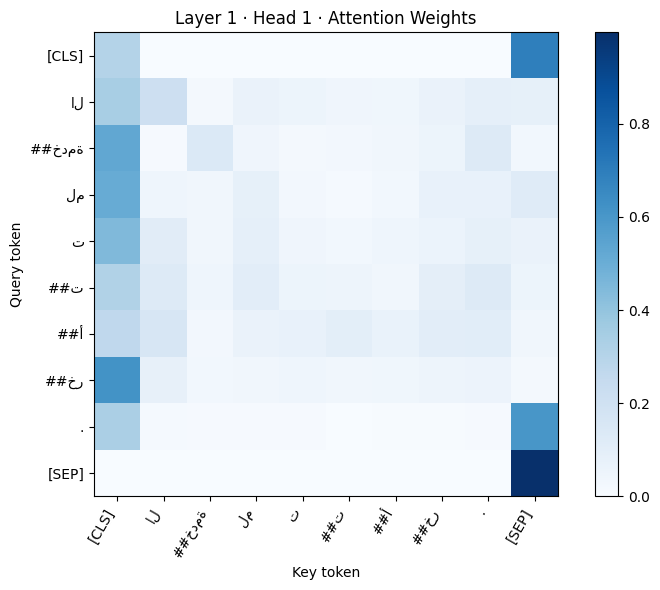

ACTUAL_TRANSFORMER_FORWARD=PASS


In [22]:
# Actual forward pass with a multilingual Transformer

import torch
import matplotlib.pyplot as plt

from transformers import AutoModel, AutoTokenizer
from transformers.utils import logging as hf_logging


hf_logging.set_verbosity_error()

MODEL_NAME = "distilbert/distilbert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

model = AutoModel.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager"
)

model.eval()


example_sentences = [
    "الخدمة لم تتأخر.",
    "The service was not delayed."
]

model_inputs = tokenizer(
    example_sentences,
    padding=True,
    truncation=True,
    max_length=32,
    return_tensors="pt"
)


with torch.no_grad():
    model_output = model(
        **model_inputs,
        output_attentions=True
    )


total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

hidden_state_shape = tuple(
    model_output.last_hidden_state.shape
)

attention_tensor_shape = tuple(
    model_output.attentions[0].shape
)

arabic_tokens = tokenizer.convert_ids_to_tokens(
    model_inputs["input_ids"][0]
)

valid_token_count = int(
    model_inputs["attention_mask"][0].sum()
)

first_head_attention = (
    model_output.attentions[0][
        0,
        0,
        :valid_token_count,
        :valid_token_count
    ]
    .cpu()
    .numpy()
)


print("Model:", MODEL_NAME)
print(f"Parameters: {total_parameters:,}")
print("Hidden-state shape:", hidden_state_shape)

print(
    "Attention tensor [batch, heads, query, key]:",
    attention_tensor_shape
)

print(
    "Arabic tokens:",
    arabic_tokens[:valid_token_count]
)

print(
    "Row-sum range:",
    float(first_head_attention.sum(-1).min()),
    float(first_head_attention.sum(-1).max())
)


fig, ax = plt.subplots(figsize=(8, 6))

heatmap = ax.imshow(
    first_head_attention,
    cmap="Blues",
    vmin=0.0
)

ax.set_xticks(
    range(valid_token_count),
    arabic_tokens[:valid_token_count],
    rotation=60,
    ha="right"
)

ax.set_yticks(
    range(valid_token_count),
    arabic_tokens[:valid_token_count]
)

ax.set_xlabel("Key token")
ax.set_ylabel("Query token")

ax.set_title(
    "Layer 1 · Head 1 · Attention Weights"
)

fig.colorbar(
    heatmap,
    ax=ax,
    fraction=0.046
)

fig.tight_layout()
plt.show()


assert total_parameters > 100_000_000

assert hidden_state_shape[:2] == tuple(
    model_inputs["input_ids"].shape
)

assert (
    attention_tensor_shape[0] == 2
    and attention_tensor_shape[2] == attention_tensor_shape[3]
)

assert np.allclose(
    first_head_attention.sum(-1),
    1.0,
    atol=1e-5
)

print("ACTUAL_TRANSFORMER_FORWARD=PASS")

In [23]:
# Final checks for Notebook 2

core_checks = {
    "weights_sum_to_one":
        np.allclose(
            attention_weights.sum(axis=-1),
            1.0
        ),

    "two_checkpoint_parameter_audit":
        len(audit_results) == 2
        and all(
            result["total_parameters"]
            == EXPECTED_PARAMETER_TOTALS[result["model_name"]]
            for result in audit_results
        ),

    "actual_forward":
        total_parameters > 100_000_000
        and len(model_output.attentions) > 0,

    "output_shape":
        attention_output.shape == (2, 2),

    "masked_positions_zero":
        masked_weights[0, 1] == 0
        and masked_weights[0, 2] == 0,

    "heads_round_trip":
        np.allclose(
            combined_tensor,
            sample_tensor
        ),
}


for check_name, passed in core_checks.items():
    status = "PASS" if passed else "FAIL"
    print(f"{check_name}: {status}")


assert all(core_checks.values())

print("DAY1_NOTEBOOK2_CORE=PASS")

weights_sum_to_one: PASS
two_checkpoint_parameter_audit: PASS
actual_forward: PASS
output_shape: PASS
masked_positions_zero: PASS
heads_round_trip: PASS
DAY1_NOTEBOOK2_CORE=PASS


In [24]:
# Challenge 9 - Core
# Change V values and observe how the attention output changes

new_values = np.array([
    [20.0, 0.0],
    [0.0, 20.0],
    [10.0, 10.0]
])

new_output, new_weights, _ = compute_attention(
    queries,
    keys,
    new_values
)

print("Original output:")
print(np.round(attention_output, 3))

print("\nNew output after changing V:")
print(np.round(new_output, 3))

print("\nAttention weights:")
print(np.round(new_weights, 3))

print("\nObservation:")
print("Changing V changes the final output, while the attention weights remain based on Q and K.")

Original output:
[[6.017 3.983]
 [3.983 6.017]]

New output after changing V:
[[12.033  7.967]
 [ 7.967 12.033]]

Attention weights:
[[0.401 0.198 0.401]
 [0.198 0.401 0.401]]

Observation:
Changing V changes the final output, while the attention weights remain based on Q and K.
